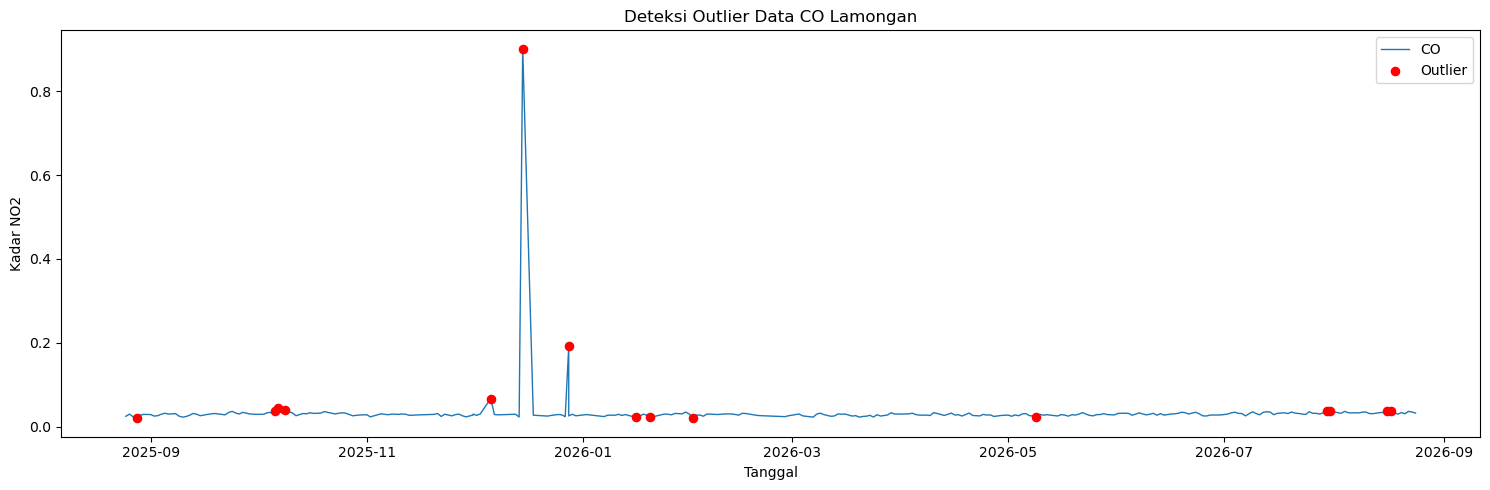

date     0
CO      76
dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

df = pd.read_csv("CO_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "CO"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

df_clean["outlier"] = model.fit_predict(
    df_clean[["CO"]]
)

# Memisahkan outlier
outliers = df_clean[df_clean["outlier"] == -1]

plt.figure(figsize=(15, 5))

plt.plot(
    df_clean["date"],
    df_clean["CO"],
    linewidth=1,
    label="CO"
)

plt.scatter(
    outliers["date"],
    outliers["CO"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data CO Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()
print(df.isnull().sum())


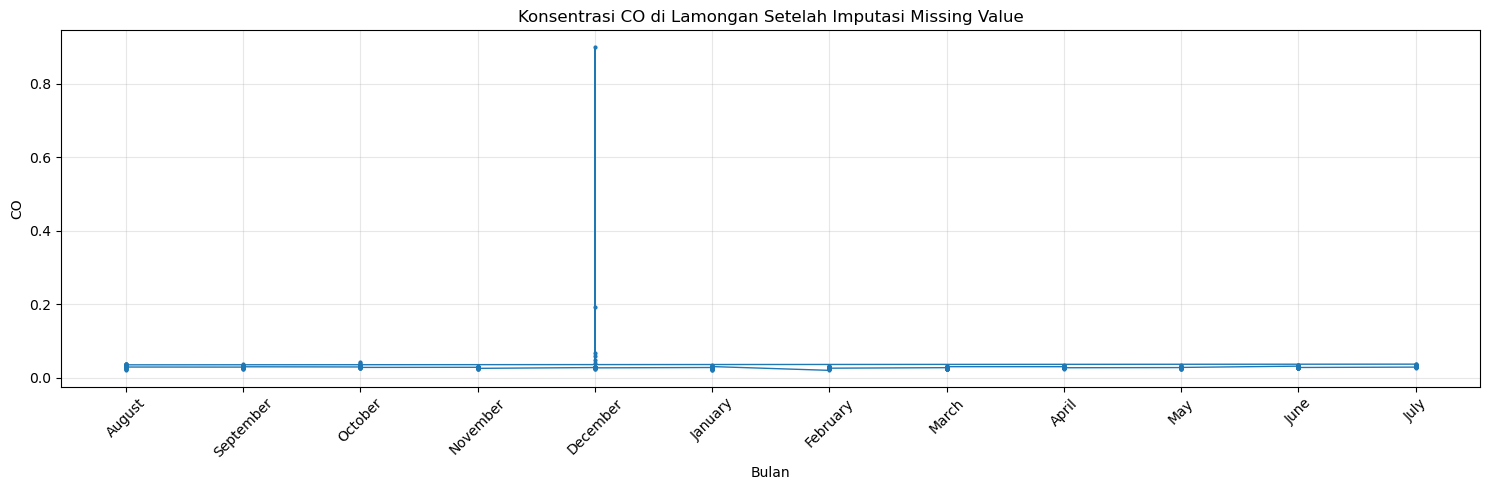


Missing value setelah imputasi:
0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Membaca data
df = pd.read_csv("CO_lamongan_sorted.csv")

# Mengubah date menjadi format tanggal
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Mengubah CO menjadi numerik
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Mengisi missing value
df["CO"] = df["CO"].interpolate(method="linear")
df["CO"] = df["CO"].ffill()
df["CO"] = df["CO"].bfill()

# Membuat kolom bulan
df["bulan"] = df["date"].dt.strftime("%B")

# Membuat grafik
plt.figure(figsize=(15, 5))

plt.plot(
    df["bulan"],
    df["CO"],
    marker="o",
    markersize=2,
    linewidth=1
)

plt.title("Konsentrasi CO di Lamongan Setelah Imputasi Missing Value")
plt.xlabel("Bulan")
plt.ylabel("CO")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nMissing value setelah imputasi:")
print(df["CO"].isnull().sum())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("CO_lamongan_sorted.csv")
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# Menghitung Q1 dan Q3
Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

# Menghitung IQR
IQR = Q3 - Q1

# Menentukan batas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan status data
df["status"] = df["CO"].apply(
    lambda x: "Outlier"
    if x < batas_bawah or x > batas_atas
    else "Normal"
)
outliers_iqr = df[df["status"] == "Outlier"]

print("\nJumlah data:")
print(df["status"].value_counts())

print("\nData Outlier:")
print(df[df["status"] == "Outlier"][["date", "CO"]])


Jumlah data:
status
Normal     356
Outlier     10
Name: count, dtype: int64

Data Outlier:
           date        CO
44   2025-10-07  0.043492
46   2025-10-09  0.039035
103  2025-12-04  0.039578
104  2025-12-05  0.048821
105  2025-12-06  0.058064
106  2025-12-06  0.067307
114  2025-12-15  0.901257
126  2025-12-28  0.191613
161  2026-02-01  0.020215
358  2026-08-17  0.038314


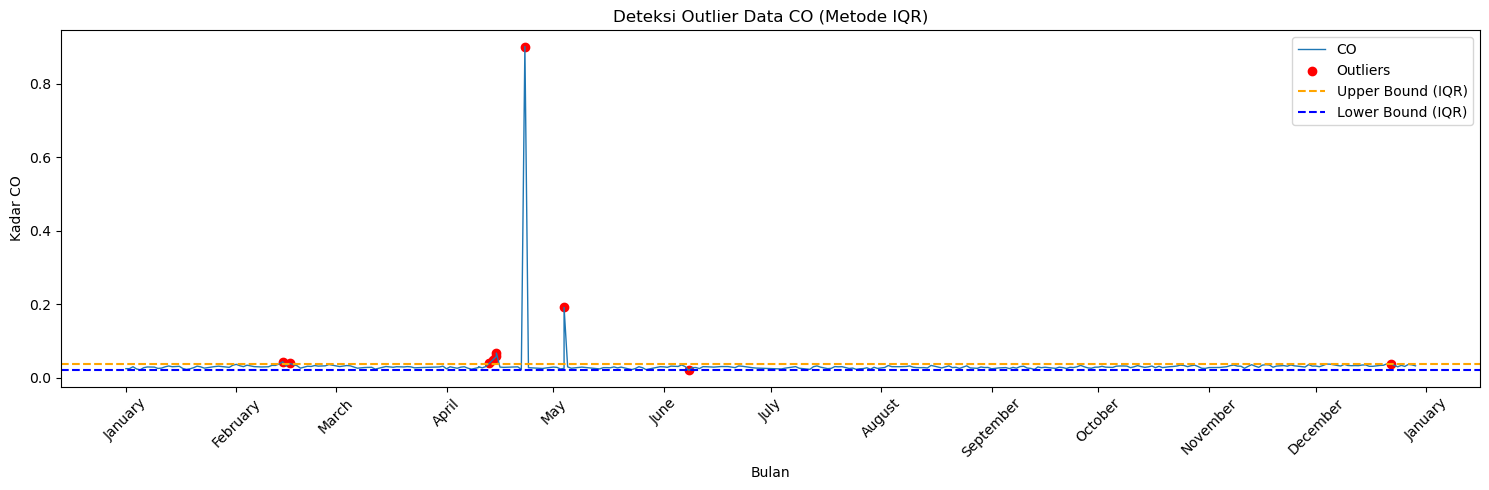

In [ ]:
plt.figure(figsize=(15, 5))

# Grafik CO
plt.plot(
    df["date"],
    df["CO"],
    label="CO",
    linewidth=1
)

# Titik outlier
plt.scatter(
    outliers_iqr["date"],
    outliers_iqr["CO"],
    color="red",
    marker="o",
    label="Outliers"
)

# Batas atas IQR
plt.axhline(
    batas_atas,
    color="orange",
    linestyle="dashed",
    label="Upper Bound (IQR)"
)

# Batas bawah IQR
plt.axhline(
    batas_bawah,
    color="blue",
    linestyle="dashed",
    label="Lower Bound (IQR)"
)

# Judul dan label
plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Bulan")
plt.ylabel("Kadar CO")

# Menampilkan bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Membaca data
df = pd.read_csv("CO_lamongan_sorted.csv")

# Mengubah CO menjadi numerik
df["CO"] = pd.to_numeric(df["CO"], errors="coerce")

# =========================
# DETEKSI OUTLIER DENGAN IQR
# =========================

Q1 = df["CO"].quantile(0.25)
Q3 = df["CO"].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Menentukan data outlier
outlier = (
    (df["CO"] < batas_bawah) |
    (df["CO"] > batas_atas)
)

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Batas bawah:", batas_bawah)
print("Batas atas:", batas_atas)

print("\nJumlah data sebelum penanganan:", len(df))
print("Jumlah outlier:", outlier.sum())

# =========================
# MENANGANI OUTLIER
# =========================

# Outlier diubah menjadi NaN
df.loc[outlier, "CO"] = None

# Mengisi nilai outlier dengan Linear Interpolation
df["CO"] = df["CO"].interpolate(method="linear")

# Menangani NaN jika berada di awal atau akhir data
df["CO"] = df["CO"].ffill().bfill()

print("\nJumlah missing setelah penanganan:",
      df["CO"].isna().sum())

print("Data setelah outlier ditangani:")
print(df.head(10))

df.to_csv("CO_lamongan_fix.csv", index=False)

print("\nFile berhasil disimpan sebagai:")
print("CO_lamongan_fix.csv")

Q1: 0.027159144723235225
Q3: 0.0315967946680206
IQR: 0.004437649944785377
Batas bawah: 0.02050266980605716
Batas atas: 0.03825326958519867

Jumlah data sebelum penanganan: 366
Jumlah outlier: 10

Jumlah missing setelah penanganan: 0
Data setelah outlier ditangani:
         date        CO
0  2025-08-24  0.024864
1  2025-08-25  0.024864
2  2025-08-26  0.030086
3  2025-08-27  0.024034
4  2025-08-28  0.021727
5  2025-08-29  0.027486
6  2025-08-30  0.029433
7  2025-08-31  0.029251
8  2025-09-01  0.029069
9  2025-09-02  0.025398

File berhasil disimpan sebagai:
CO_lamongan_fix.csv


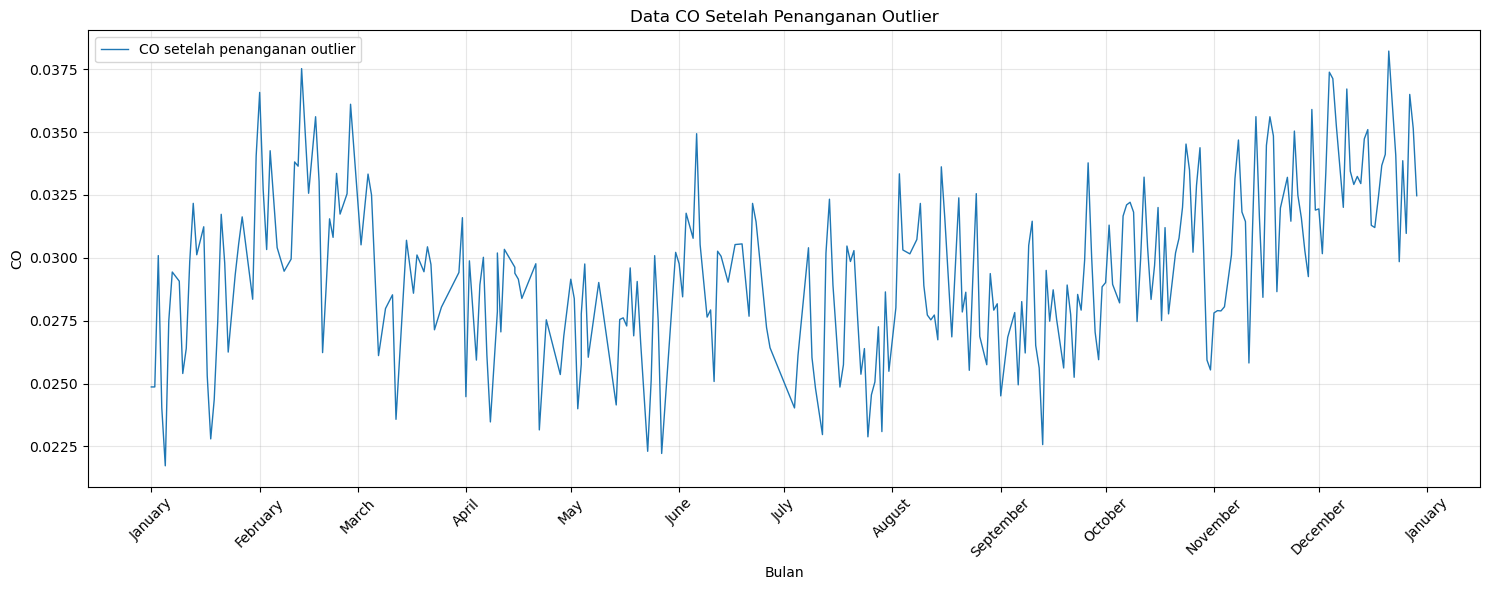

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

plt.plot(
    df["date"],
    df["CO"],
    linewidth=1,
    label="CO setelah penanganan outlier"
)

plt.title("Data CO Setelah Penanganan Outlier")
plt.xlabel("Bulan")
plt.ylabel("CO")

# Menampilkan nama bulan pada sumbu X
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%B"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("No2_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["NO2"] = pd.to_numeric(df["NO2"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "NO2"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["NO2"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["NO2"], linewidth=1, label="NO2")
plt.scatter(
    outliers["date"],
    outliers["NO2"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data NO2 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("So2_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["SO2"] = pd.to_numeric(df["SO2"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "SO2"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["SO2"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["SO2"], linewidth=1, label="SO2")
plt.scatter(
    outliers["date"],
    outliers["SO2"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data SO2 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Membaca data
df = pd.read_csv("O3_lamongan.csv")

# Cleaning
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["O3"] = pd.to_numeric(df["O3"], errors="coerce")

df_clean = (
    df.dropna(subset=["date", "O3"])
      .sort_values("date")
      .reset_index(drop=True)
)

# Isolation Forest
model = IsolationForest(contamination=0.05, random_state=42)
df_clean["outlier"] = model.fit_predict(df_clean[["O3"]])

outliers = df_clean[df_clean["outlier"] == -1]

# Grafik
plt.figure(figsize=(15, 5))
plt.plot(df_clean["date"], df_clean["O3"], linewidth=1, label="O3")
plt.scatter(
    outliers["date"],
    outliers["O3"],
    color="red",
    s=35,
    label="Outlier",
    zorder=5
)

plt.title("Deteksi Outlier Data O3 Lamongan")
plt.xlabel("Tanggal")
plt.ylabel("Kadar O3")
plt.legend()
plt.tight_layout()
plt.show()